<a href="https://colab.research.google.com/github/Balamurugan-T326/Machine-Learning/blob/main/Experiment-9/sc-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Roll No: 24BAD016
# Name: Balamurugan T

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from math import sqrt

In [12]:
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [13]:
print(ratings.info())
print(ratings.describe())

print("Total Users:", ratings['userId'].nunique())
print("Total Movies:", ratings['movieId'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
std       182.618491   35530.987199       1.042529  2.162610e+08
min         1.000000       1.000000       0.500000  8.281246e+08
25%       177.000000    1199.000000       3.000000  1.019124e+09
50%       325.000000    2991.000000       3.500000  1.186087e+09
75%       477.000000    8122.000000       4.000000  1.435994e+09
max       610.000000  193609.000000       5.000000  1.537799e+09
Tota

In [14]:
item_user_matrix = ratings.pivot(index='movieId', columns='userId', values='rating')

item_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
item_user_matrix_filled = item_user_matrix.fillna(0)

In [16]:
item_similarity = cosine_similarity(item_user_matrix_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
def get_similar_items(movie_id, n=5):
    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)
    return similar_items.iloc[1:n+1]

get_similar_items(1)

,1
movieId,
3114,0.572601
480,0.565637
780,0.564262
260,0.557388
356,0.547096


In [18]:
def predict_rating(user_id, movie_id):
    similar_items = item_similarity_df[movie_id]

    user_ratings = item_user_matrix[user_id]

    numerator = 0
    denominator = 0

    for item, similarity in similar_items.items():
        rating = user_ratings[item]

        if not np.isnan(rating):
            numerator += similarity * rating
            denominator += abs(similarity)

    if denominator == 0:
        return 0

    return numerator / denominator

predict_rating(1, 10)

np.float64(4.347789612540203)

In [21]:
def predict_rating(user_id, movie_id):
    if movie_id not in item_similarity_df:
        return 0

    similar_items = item_similarity_df[movie_id]

    user_ratings = item_user_matrix[user_id]


    rated_items = user_ratings[user_ratings.notna()]

    similar_items = similar_items[rated_items.index]

    numerator = np.dot(similar_items, rated_items)
    denominator = np.sum(np.abs(similar_items))

    if denominator == 0:
        return 0

    return numerator / denominator

In [22]:
y_true = []
y_pred = []

for row in ratings.itertuples():
    pred = predict_rating(row.userId, row.movieId)

    if pred > 0:
        y_true.append(row.rating)
        y_pred.append(pred)

rmse = sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 0.8892766910449942


In [23]:
def precision_at_k(user_id, k=5):
    recommended = recommend_movies(user_id, k)['movieId'].values
    actual = ratings[ratings['userId'] == user_id]['movieId'].values

    relevant = set(recommended) & set(actual)

    return len(relevant) / k

print("Precision@K:", precision_at_k(1))

Precision@K: 0.0


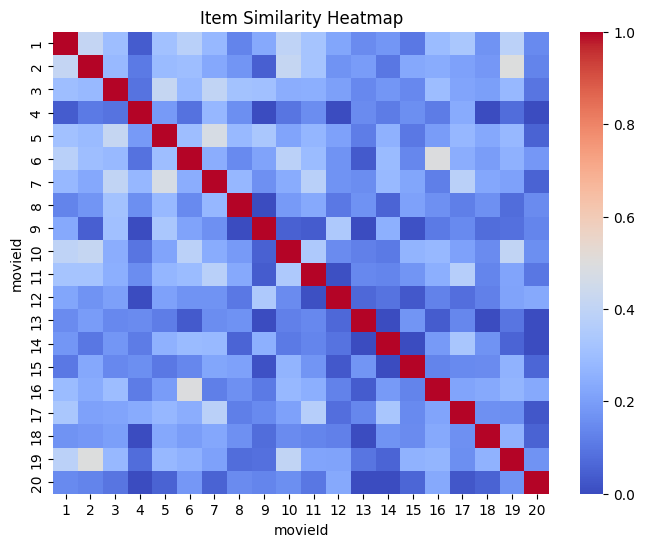

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.show()

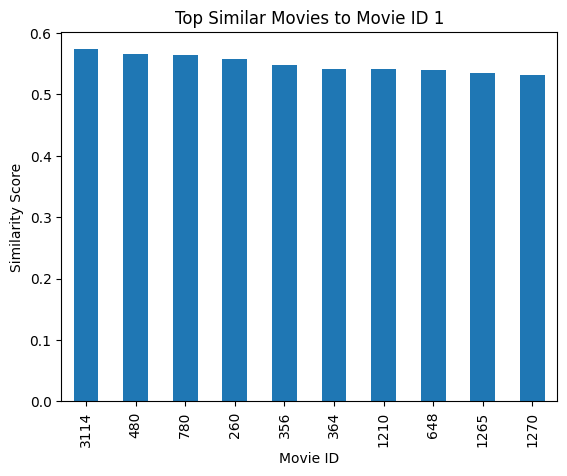

In [25]:
similar_items = get_similar_items(1, 10)

similar_items.plot(kind='bar')
plt.title("Top Similar Movies to Movie ID 1")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()